In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

def epsilon_greedy_action(Q, state, epsilon, n_actions):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    return int(np.argmax(Q[state]))

def moving_average(values, window=100):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return values
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(values, kernel, mode="valid")

In [2]:
def train_sarsa_lambda_taxi(
    lambda_value,
    episodes=2500,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05,
    max_steps=200,
    seed=SEED,
):
    env = gym.make("Taxi-v3")
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions), dtype=np.float32)
    epsilon = epsilon_start

    episode_rewards = []
    episode_steps = []

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        action = epsilon_greedy_action(Q, state, epsilon, n_actions)
        eligibility = np.zeros_like(Q, dtype=np.float32)

        total_reward = 0.0
        steps = 0

        for _ in range(max_steps):
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward
            steps += 1

            if done:
                td_target = reward
                td_error = td_target - Q[state, action]
                eligibility[state, action] += 1.0
                Q += alpha * td_error * eligibility
                break

            next_action = epsilon_greedy_action(Q, next_state, epsilon, n_actions)
            td_target = reward + gamma * Q[next_state, next_action]
            td_error = td_target - Q[state, action]

            eligibility[state, action] += 1.0
            Q += alpha * td_error * eligibility
            eligibility *= gamma * lambda_value

            state = next_state
            action = next_action

        episode_rewards.append(total_reward)
        episode_steps.append(steps)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()
    return Q, episode_rewards, episode_steps

def evaluate_taxi_policy(Q, episodes=500, max_steps=200, seed=10000):
    env = gym.make("Taxi-v3")

    returns = []
    steps_list = []
    successes = 0

    for episode in range(episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0
        last_reward = 0.0

        for step in range(max_steps):
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            last_reward = reward

            if terminated or truncated:
                steps_list.append(step + 1)
                break
        else:
            steps_list.append(max_steps)

        if last_reward == 20:
            successes += 1
        returns.append(total_reward)

    env.close()
    mean_return = float(np.mean(returns))
    success_rate = 100.0 * successes / episodes
    mean_steps = float(np.mean(steps_list))
    return mean_return, success_rate, mean_steps

In [3]:
lambda_values = [0.0, 0.3, 0.6, 0.9, 1.0]
results = {}

common_params = dict(
    episodes=2500,
    alpha=0.1,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_decay=0.999,
    epsilon_min=0.05,
    max_steps=200,
    seed=SEED,
)

for lam in lambda_values:
    print(f"Training SARSA(lambda) with lambda = {lam}")
    Q, train_rewards, train_steps = train_sarsa_lambda_taxi(lambda_value=lam, **common_params)
    eval_return, eval_success, eval_steps = evaluate_taxi_policy(Q)

    results[lam] = {
        "Q": Q,
        "train_rewards": train_rewards,
        "train_steps": train_steps,
        "eval_return": eval_return,
        "eval_success": eval_success,
        "eval_steps": eval_steps,
    }

print("\nTraining complete for all lambda values.")

Training SARSA(lambda) with lambda = 0.0
Training SARSA(lambda) with lambda = 0.3
Training SARSA(lambda) with lambda = 0.6
Training SARSA(lambda) with lambda = 0.9
Training SARSA(lambda) with lambda = 1.0

Training complete for all lambda values.


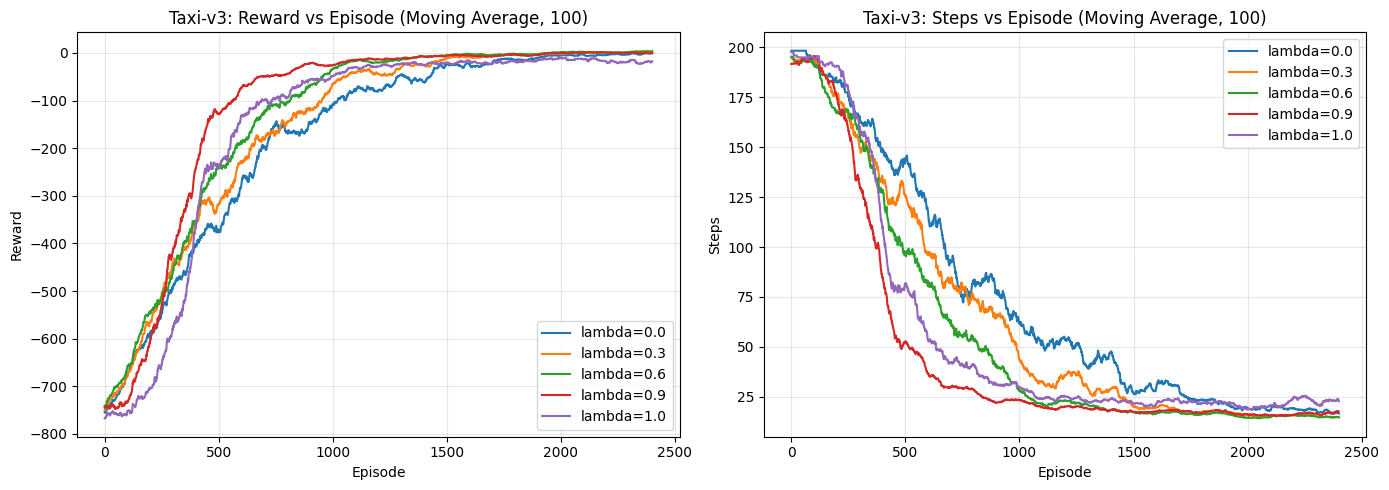


Exercise 11: SARSA(lambda) in Taxi-v3
----------------------------------------------------------------------------------------
lambda  | Last-200 Avg Reward | Last-200 Avg Steps | Eval Avg Return | Eval Success % | Eval Avg Steps
----------------------------------------------------------------------------------------
   0.0 |               -1.68 |              17.50 |          -32.80 |          80.20 |          49.65
   0.3 |                2.84 |              15.01 |            2.91 |          97.60 |          17.58
   0.6 |                2.48 |              14.87 |            6.58 |          99.40 |          14.29
   0.9 |               -0.34 |              17.02 |          -15.30 |          90.60 |          30.73
   1.0 |              -17.62 |              22.38 |         -202.86 |          80.20 |          50.62

Observation:
lambda=0.0 is equivalent to one-step SARSA.
Best lambda from this run (by greedy evaluation return): 0.6


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lam in lambda_values:
    axes[0].plot(moving_average(results[lam]["train_rewards"], window=100), label=f"lambda={lam}")

axes[0].set_title("Taxi-v3: Reward vs Episode (Moving Average, 100)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for lam in lambda_values:
    axes[1].plot(moving_average(results[lam]["train_steps"], window=100), label=f"lambda={lam}")

axes[1].set_title("Taxi-v3: Steps vs Episode (Moving Average, 100)")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nExercise 11: SARSA(lambda) in Taxi-v3")
print("-" * 88)
print("lambda  | Last-200 Avg Reward | Last-200 Avg Steps | Eval Avg Return | Eval Success % | Eval Avg Steps")
print("-" * 88)

best_lambda = None
best_eval_return = -1e9

for lam in lambda_values:
    last_200_reward = float(np.mean(results[lam]["train_rewards"][-200:]))
    last_200_steps = float(np.mean(results[lam]["train_steps"][-200:]))
    eval_return = results[lam]["eval_return"]
    eval_success = results[lam]["eval_success"]
    eval_steps = results[lam]["eval_steps"]

    if eval_return > best_eval_return:
        best_eval_return = eval_return
        best_lambda = lam

    print(f"{lam:>6.1f} | {last_200_reward:>19.2f} | {last_200_steps:>18.2f} | {eval_return:>15.2f} | {eval_success:>14.2f} | {eval_steps:>14.2f}")

print("\nObservation:")
print("lambda=0.0 is equivalent to one-step SARSA.")
print(f"Best lambda from this run (by greedy evaluation return): {best_lambda}")